# Notebook 05: Detección de anomalías estadística (Mahalanobis)

Baseline multivariado para detectar días donde la **configuración global de la curva** es estadísticamente inusual.

**Motivación:**  
El z-score univariado (NB04) detecta si un bono individual se aleja de la curva del día. Este notebook sube un nivel: detecta si la *forma completa de la curva* — representada por sus parámetros Nelson-Siegel — es inusual en conjunto.  
Un z-score por bono es ciego a correlaciones entre bonos. La distancia de Mahalanobis capta cuando múltiples parámetros se desvían simultáneamente en una dirección inusual.

**Método:**

$$D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \, \boldsymbol{\Sigma}^{-1} \, (\mathbf{x} - \boldsymbol{\mu})}$$

donde $\mathbf{x} = [\beta_0, \beta_1, \beta_2, \lambda]$ es el vector de parámetros NS del día.  
Bajo distribución normal multivariada, $D_M^2 \sim \chi^2(k)$ con $k$ = número de features.  
La covarianza $\boldsymbol{\Sigma}$ se estima con **LedoitWolf** (shrinkage regularizado), robusto con pocas observaciones.

**Ventaja sobre el autoencoder (NB06):**  
Funciona desde el primer día. No requiere período de entrenamiento extenso.  
El umbral tiene interpretación formal (percentil chi²). Es el baseline que opera mientras el autoencoder acumula datos.

**Contenido:**
1. Setup + carga de datos
2. Ajuste NS diario + extracción de parámetros
3. Rolling z-score de cada parámetro NS (análisis univariado)
4. Distancia de Mahalanobis por grupo (LECER / CER)
5. Días anómalos: tabla y contexto
6. Snapshot del estado actual

In [15]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from dotenv import load_dotenv
load_dotenv(os.path.join(project_root, '.env'))

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
from scipy.stats import chi2
from sklearn.covariance import LedoitWolf
from sqlalchemy import text
from src.db.session import SessionLocal

print('Setup OK')

Setup OK


In [16]:
# ─────────────────────────────────────────
#  PARÁMETROS — modificar acá
# ─────────────────────────────────────────
FECHA_INICIO_LECER = '2026-02-02'   # primer día con ≥5 LECER vigentes
FECHA_INICIO_CER   = '2025-12-08'   # régimen actual (definido en NB02)

MIN_BONOS_LECER = 5
MIN_BONOS_CER   = 14

# Ventanas rolling para z-scores univariados de parámetros NS
VENTANA_Z_LECER = 10   # días
VENTANA_Z_CER   = 20   # días

# Ventana Mahalanobis: None = expanding window (train en todos los días anteriores)
VENTANA_MAH = None

# Mínimos de observaciones para estimar covarianza (debe superar k features)
MIN_OBS_MAH_LECER = 6
MIN_OBS_MAH_CER   = 8

# Nivel de significancia para umbral Mahalanobis
ALPHA_MAH = 0.05

# Features del vector NS
COLS_NS = ['beta0', 'beta1', 'beta2', 'lam']

In [17]:
# ── Carga de datos ────────────────────────────────────────────
with SessionLocal() as db:
    df_lecer = pd.read_sql(
        text("""
            SELECT p.ticker, p.fecha, m.tir, m.duration_modificada
            FROM precios_raw p
            JOIN metricas_diarias m ON m.precio_id = p.id
            JOIN bonos b ON b.ticker = p.ticker
            WHERE b.grupo = 'lecer'
              AND p.fecha >= :inicio
            ORDER BY p.fecha, m.duration_modificada
        """),
        db.bind,
        params={'inicio': FECHA_INICIO_LECER},
        parse_dates=['fecha']
    )
    df_cer = pd.read_sql(
        text("""
            SELECT p.ticker, p.fecha, m.tir, m.duration_modificada
            FROM precios_raw p
            JOIN metricas_diarias m ON m.precio_id = p.id
            JOIN bonos b ON b.ticker = p.ticker
            WHERE b.grupo = 'cer'
              AND p.fecha >= :inicio
            ORDER BY p.fecha, m.duration_modificada
        """),
        db.bind,
        params={'inicio': FECHA_INICIO_CER},
        parse_dates=['fecha']
    )

for _df in (df_lecer, df_cer):
    _df['tir']                = _df['tir'].astype(float)
    _df['duration_modificada'] = _df['duration_modificada'].astype(float)

df_lecer = df_lecer.dropna(subset=['tir', 'duration_modificada'])
df_cer   = df_cer.dropna(subset=['tir', 'duration_modificada'])

print(f'LECER: {len(df_lecer):,} obs | {df_lecer["fecha"].nunique()} días | '
      f'{df_lecer["fecha"].min().date()} → {df_lecer["fecha"].max().date()}')
print(f'CER:   {len(df_cer):,} obs | {df_cer["fecha"].nunique()} días | '
      f'{df_cer["fecha"].min().date()} → {df_cer["fecha"].max().date()}')

LECER: 131 obs | 25 días | 2026-02-02 → 2026-03-08
CER:   942 obs | 60 días | 2025-12-09 → 2026-03-08


In [18]:
# ── Modelo Nelson-Siegel (idéntico a NB03/NB04) ───────────────

def nelson_siegel(tau, beta0, beta1, beta2, lam):
    with np.errstate(over='ignore', invalid='ignore'):
        x  = tau / lam
        f1 = np.where(x < 1e-10, 1.0, (1.0 - np.exp(-x)) / x)
        f2 = f1 - np.exp(-x)
    return beta0 + beta1 * f1 + beta2 * f2


def ajustar_ns_dia(df_dia, lam_fijo=None, min_puntos=3):
    df_dia = df_dia[df_dia['duration_modificada'] > 0].dropna(subset=['tir', 'duration_modificada'])
    if len(df_dia) < min_puntos:
        return None

    d       = df_dia['duration_modificada'].values
    y       = df_dia['tir'].values
    tickers = df_dia['ticker'].values
    idx     = np.argsort(d)
    slope_init = float(y[idx[0]] - y[idx[-1]])

    try:
        if lam_fijo is not None:
            def ns_fixed(tau, b0, b1, b2):
                return nelson_siegel(tau, b0, b1, b2, lam_fijo)
            popt, _ = curve_fit(
                ns_fixed, d, y,
                p0=[float(np.mean(y)), slope_init, 0.0],
                bounds=([-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]),
                maxfev=5000
            )
            beta0, beta1, beta2 = popt
            lam = lam_fijo
        else:
            popt, _ = curve_fit(
                nelson_siegel, d, y,
                p0=[float(np.mean(y)), slope_init, 0.0, 1.0],
                bounds=([-0.5, -0.5, -0.5, 0.05], [0.5, 0.5, 0.5, 10.0]),
                maxfev=5000
            )
            beta0, beta1, beta2, lam = popt
    except Exception:
        return None

    y_pred   = nelson_siegel(d, beta0, beta1, beta2, lam)
    resid_pp = (y - y_pred) * 100
    rmse_pp  = float(np.sqrt(np.mean(resid_pp ** 2)))

    return {
        'beta0':      beta0,
        'beta1':      beta1,
        'beta2':      beta2,
        'lam':        lam,
        'rmse_pp':    rmse_pp,
        'residuales': dict(zip(tickers, resid_pp)),
    }


print('Funciones NS cargadas')

Funciones NS cargadas


In [19]:
# ── Ajuste NS diario + extracción de DataFrame de parámetros ──

def ajustar_y_extraer(df_raw, lam_fijo, min_bonos, nombre):
    resultados = {}
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for fecha, grupo in df_raw.groupby('fecha'):
            res = ajustar_ns_dia(grupo, lam_fijo=lam_fijo, min_puntos=min_bonos)
            if res is not None:
                resultados[fecha] = res

    rows = [
        {'fecha': f, 'beta0': r['beta0'], 'beta1': r['beta1'],
         'beta2': r['beta2'], 'lam': r['lam'], 'rmse_pp': r['rmse_pp']}
        for f, r in sorted(resultados.items())
    ]
    df_params = pd.DataFrame(rows).set_index('fecha').astype(float)

    dias_total = df_raw['fecha'].nunique()
    print(f'{nombre}: {len(df_params)} / {dias_total} días ajustados '
          f'({len(df_params)/dias_total*100:.0f}%) | '
          f'{df_params.index.min().date()} → {df_params.index.max().date()}')
    return resultados, df_params


resultados_lecer, params_lecer = ajustar_y_extraer(df_lecer, None, MIN_BONOS_LECER, 'LECER')
resultados_cer,   params_cer   = ajustar_y_extraer(df_cer,   None, MIN_BONOS_CER,   'CER')

LECER: 24 / 25 días ajustados (96%) | 2026-02-02 → 2026-03-08
CER: 59 / 60 días ajustados (98%) | 2025-12-09 → 2026-03-08


## 1. Rolling z-score de parámetros NS

Detección univariada: cada parámetro NS se analiza por separado con un z-score rolling.

| Parámetro | Interpretación | Qué implica un z extremo |
|-----------|----------------|---------------------------|
| **β₀** | Nivel general de tasas (largo plazo) | Repricing global de la curva real |
| **β₁** | Pendiente (corto − largo) | Cambio en la inclinación de la curva |
| **β₂** | Curvatura (joroba o valle en plazos medios) | Dislocación del tramo medio |
| **λ** | Escala temporal del ajuste | Inestabilidad numérica o cambio de régimen |

Un z-score extremo en un solo parámetro puede ser ruido de ajuste.  
El análisis multivariado (siguiente sección) captura cuando varios parámetros se desvían **a la vez**.

In [20]:
def calcular_zscore_params(df_params, columnas, ventana, min_periods=3):
    result = {}
    for col in columnas:
        s    = df_params[col]
        roll = s.rolling(window=ventana, min_periods=min_periods)
        mu   = roll.mean()
        std  = roll.std()
        result[col] = (s - mu) / std.replace(0, np.nan)
    return pd.DataFrame(result)


zscore_lecer = calcular_zscore_params(params_lecer, COLS_NS, VENTANA_Z_LECER)
zscore_cer   = calcular_zscore_params(params_cer,   COLS_NS, VENTANA_Z_CER)

print(f'LECER — días con al menos un z válido: {zscore_lecer.notna().any(axis=1).sum()} / {len(zscore_lecer)}')
print(f'CER   — días con al menos un z válido: {zscore_cer.notna().any(axis=1).sum()} / {len(zscore_cer)}')

LECER — días con al menos un z válido: 22 / 24
CER   — días con al menos un z válido: 57 / 59


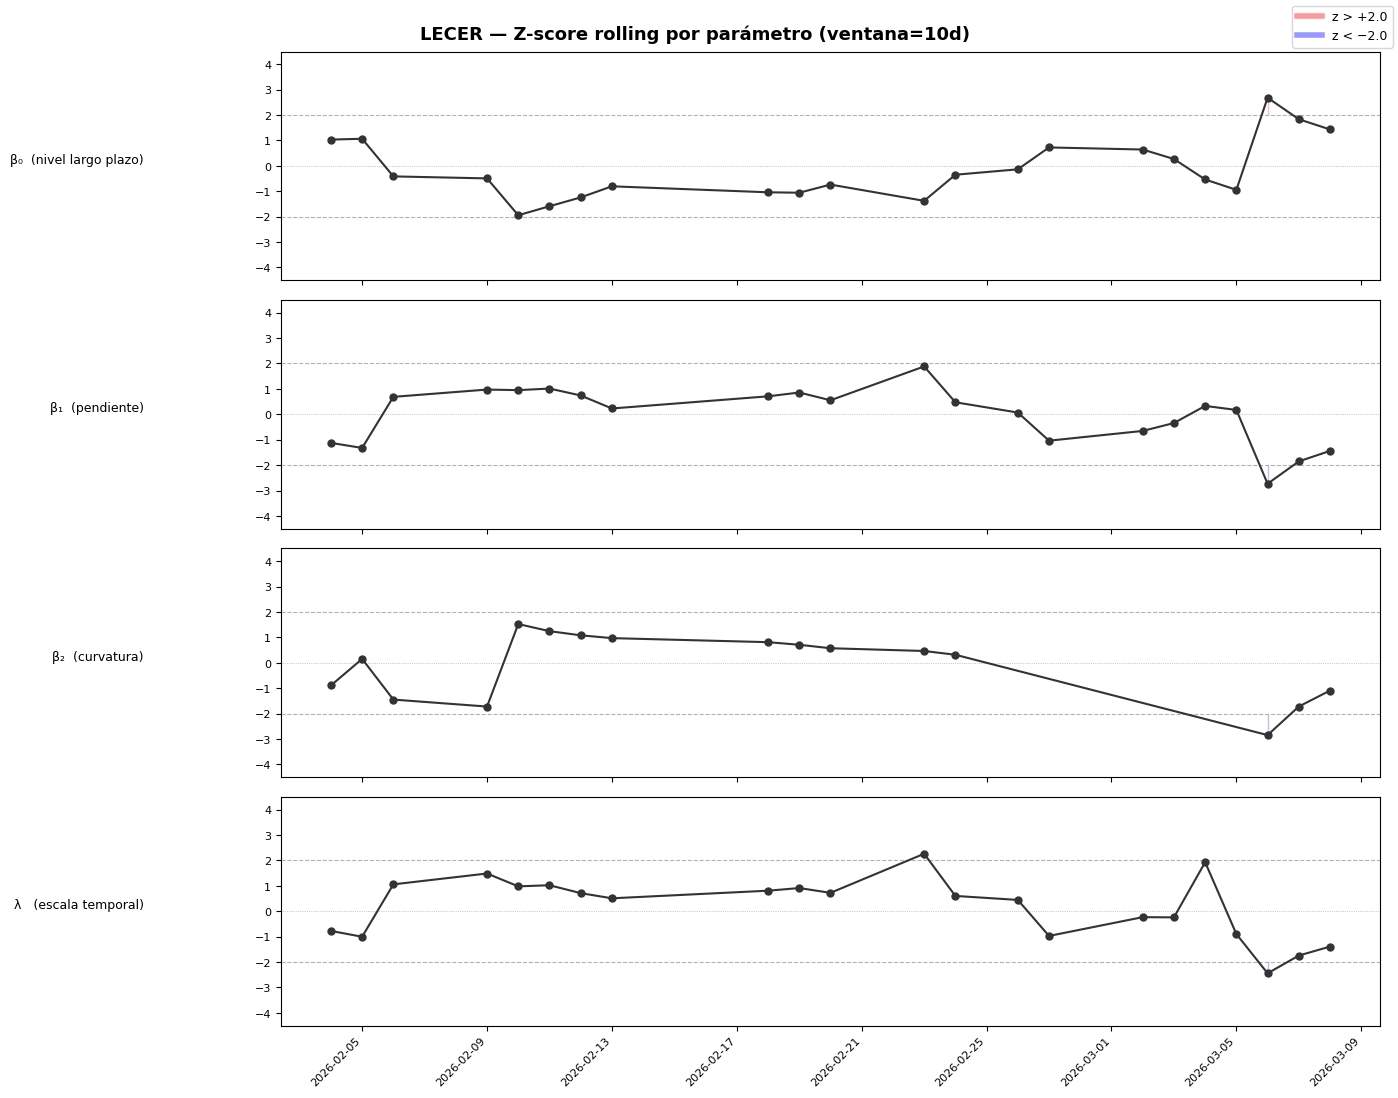

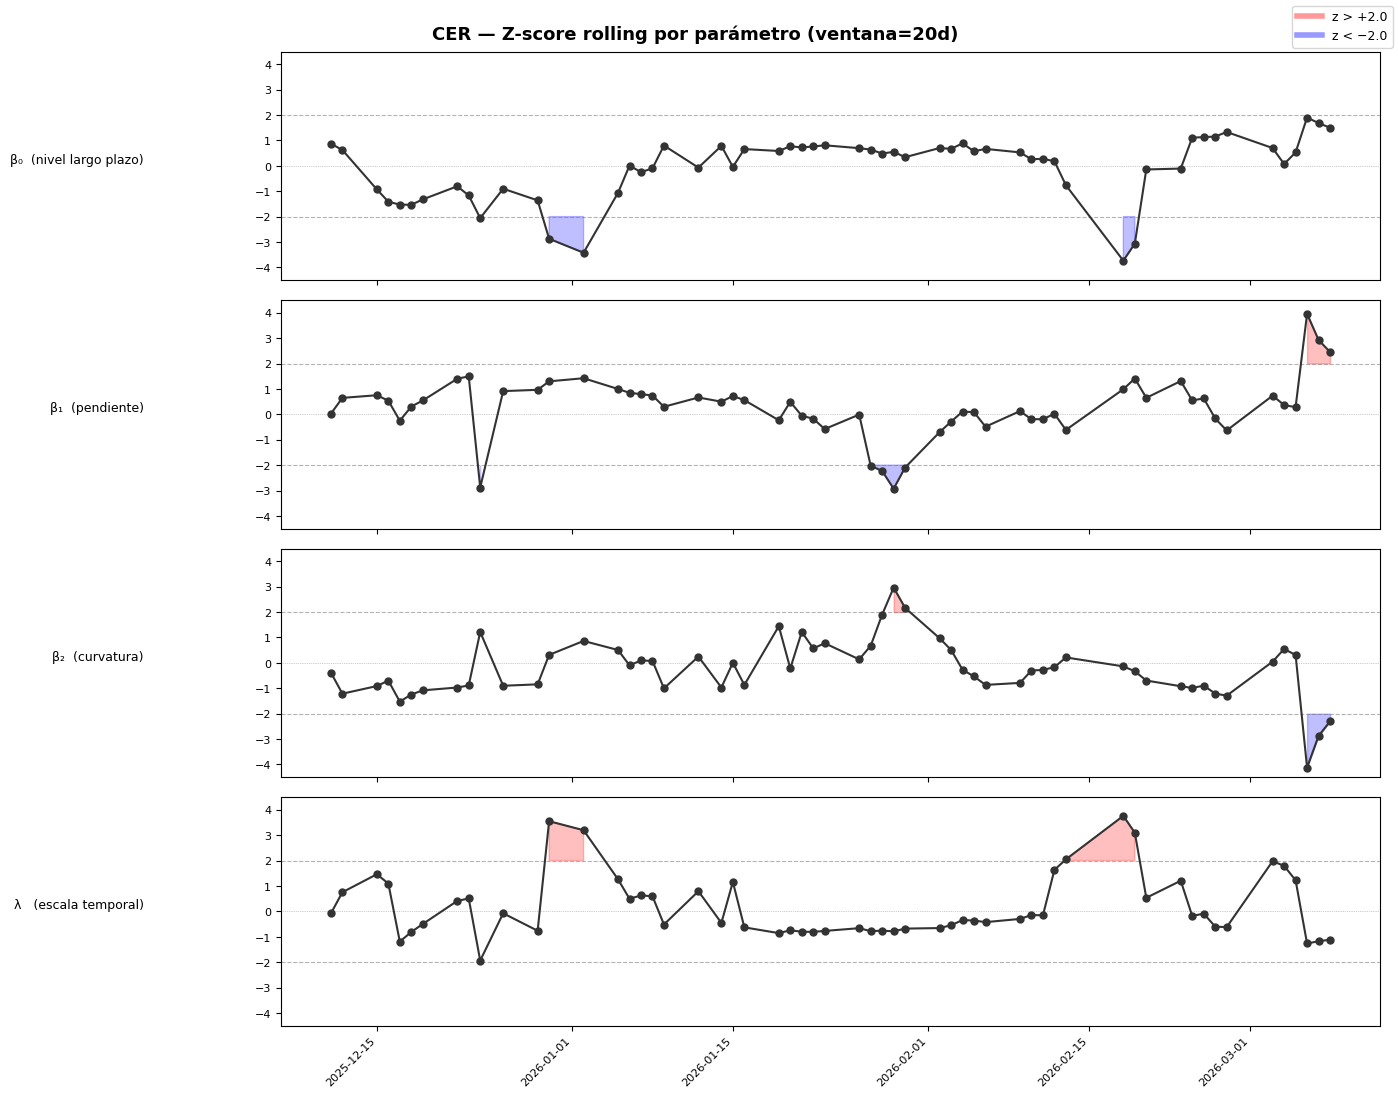

In [21]:
def plot_zscore_params(zscore_df, titulo, ventana, umbral=2.0, figsize=(14, 11)):
    labels = {
        'beta0': 'β₀  (nivel largo plazo)',
        'beta1': 'β₁  (pendiente)',
        'beta2': 'β₂  (curvatura)',
        'lam':   'λ   (escala temporal)',
    }
    cols = [c for c in COLS_NS if c in zscore_df.columns]
    fig, axes = plt.subplots(len(cols), 1, figsize=figsize, sharex=True)

    for ax, col in zip(axes, cols):
        z = zscore_df[col].dropna()
        ax.axhline( umbral, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
        ax.axhline(-umbral, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
        ax.axhline(0, color='black', linewidth=0.5, linestyle=':', alpha=0.4)

        ax.fill_between(z.index, umbral, z.values,
                        where=(z.values > umbral), alpha=0.25, color='red')
        ax.fill_between(z.index, -umbral, z.values,
                        where=(z.values < -umbral), alpha=0.25, color='blue')

        ax.plot(z.index, z.values, color='#333333', linewidth=1.5)
        ax.scatter(z.index, z.values, s=25, color='#333333', zorder=5)

        ax.set_ylabel(labels.get(col, col), fontsize=9, rotation=0,
                      ha='right', labelpad=80)
        ax.set_ylim(-4.5, 4.5)
        ax.tick_params(axis='y', labelsize=8)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right', fontsize=8)

    handles = [
        plt.Line2D([0], [0], color='red',  linewidth=4, alpha=0.4, label=f'z > +{umbral}'),
        plt.Line2D([0], [0], color='blue', linewidth=4, alpha=0.4, label=f'z < −{umbral}'),
    ]
    fig.legend(handles=handles, loc='upper right', fontsize=9)
    plt.suptitle(f'{titulo} — Z-score rolling por parámetro (ventana={ventana}d)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_zscore_params(zscore_lecer, 'LECER', VENTANA_Z_LECER)
plot_zscore_params(zscore_cer,   'CER',   VENTANA_Z_CER)

## 2. Distancia de Mahalanobis por grupo

Análisis multivariado sobre el vector $[\beta_0, \beta_1, \beta_2, \lambda]$ de cada grupo.

**Implementación:**
- Covarianza estimada con **LedoitWolf** (shrinkage regularizado) — robusta con pocas observaciones
- **Expanding window**: cada día se evalúa contra todos los días anteriores. Más robusto que rolling cuando el historial es corto
- Umbral formal: $D_M^2 \sim \chi^2(4)$ → umbral al 95%: $\sqrt{9.49} \approx 3.08$ | al 99%: $\sqrt{13.28} \approx 3.64$

**Interpretación:**
- $D_M < 3.08$ → día normal (p > 5%)
- $D_M \in [3.08,\, 3.64]$ → alerta leve (p < 5%)
- $D_M > 3.64$ → anomalía significativa (p < 1%)

In [22]:
def calcular_mahalanobis_expanding(df_params, columnas, min_obs=None):
    """
    Para cada día t, estima la covarianza con LedoitWolf sobre los días [0, t-1]
    (expanding window) y calcula la distancia de Mahalanobis del día t.

    Parámetros
    ----------
    df_params : DataFrame con índice de fechas
    columnas  : lista de columnas (features)
    min_obs   : mínimo de observaciones de entrenamiento para emitir distancia
    """
    df_clean = df_params[columnas].dropna()
    X        = df_clean.values
    fechas   = df_clean.index
    n, k     = X.shape

    if min_obs is None:
        min_obs = k + 2

    distancias = []
    for i in range(n):
        X_train = X[:i]   # todos los días anteriores (expanding)
        if len(X_train) < min_obs:
            distancias.append(np.nan)
            continue
        try:
            lw   = LedoitWolf(store_precision=True).fit(X_train)
            d_sq = float(lw.mahalanobis(X[i:i+1])[0])   # squared distance
            distancias.append(float(np.sqrt(max(d_sq, 0.0))))
        except Exception:
            distancias.append(np.nan)

    return pd.Series(distancias, index=fechas, name='mahalanobis')


# Umbrales para k=4 features
k_ns = len(COLS_NS)
UMBRAL_95 = float(np.sqrt(chi2.ppf(0.95, df=k_ns)))
UMBRAL_99 = float(np.sqrt(chi2.ppf(0.99, df=k_ns)))

print(f'Umbrales Mahalanobis (k={k_ns} features NS):')
print(f'  p=5%  → {UMBRAL_95:.3f}')
print(f'  p=1%  → {UMBRAL_99:.3f}')

Umbrales Mahalanobis (k=4 features NS):
  p=5%  → 3.080
  p=1%  → 3.644


In [23]:
mah_lecer = calcular_mahalanobis_expanding(params_lecer, COLS_NS, min_obs=MIN_OBS_MAH_LECER)
mah_cer   = calcular_mahalanobis_expanding(params_cer,   COLS_NS, min_obs=MIN_OBS_MAH_CER)

print(f'LECER — distancias válidas: {mah_lecer.notna().sum()} / {len(mah_lecer)}')
print(f'  máximo: {mah_lecer.max():.3f}   (umbral 95%: {UMBRAL_95:.3f})')
print(f'CER   — distancias válidas: {mah_cer.notna().sum()} / {len(mah_cer)}')
print(f'  máximo: {mah_cer.max():.3f}   (umbral 95%: {UMBRAL_95:.3f})')

LECER — distancias válidas: 18 / 24
  máximo: 3.687   (umbral 95%: 3.080)
CER   — distancias válidas: 51 / 59
  máximo: 22.027   (umbral 95%: 3.080)


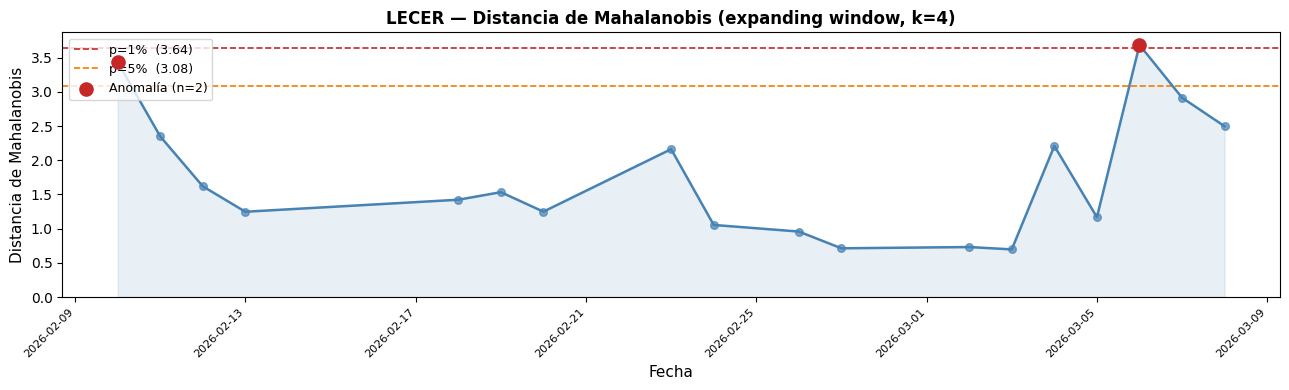

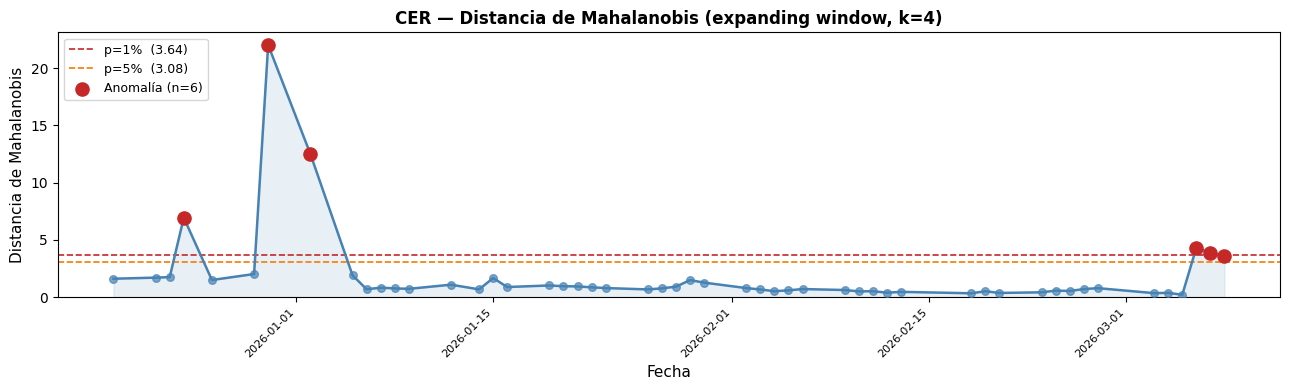

In [24]:
def plot_mahalanobis(mah_series, titulo, umbral_95, umbral_99, figsize=(13, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    s = mah_series.dropna()

    ax.axhline(umbral_99, color='#C62828', linewidth=1.2, linestyle='--',
               label=f'p=1%  ({umbral_99:.2f})')
    ax.axhline(umbral_95, color='#F57C00', linewidth=1.2, linestyle='--',
               label=f'p=5%  ({umbral_95:.2f})')
    ax.axhline(0, color='black', linewidth=0.4, linestyle=':', alpha=0.3)

    ax.fill_between(s.index, 0, s.values, alpha=0.12, color='steelblue')
    ax.plot(s.index, s.values, color='steelblue', linewidth=1.8, zorder=4)
    ax.scatter(s.index, s.values, s=30, color='steelblue', zorder=5, alpha=0.7)

    # Días anómalos destacados
    anomalos = s[s > umbral_95]
    if len(anomalos) > 0:
        ax.scatter(anomalos.index, anomalos.values,
                   color='#C62828', s=90, zorder=6, label=f'Anomalía (n={len(anomalos)})')

    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_ylabel('Distancia de Mahalanobis', fontsize=11)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=9, loc='upper left')
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()


plot_mahalanobis(mah_lecer,
                 'LECER — Distancia de Mahalanobis (expanding window, k=4)',
                 UMBRAL_95, UMBRAL_99)
plot_mahalanobis(mah_cer,
                 'CER — Distancia de Mahalanobis (expanding window, k=4)',
                 UMBRAL_95, UMBRAL_99)

## 3. Días anómalos: tabla y contexto

Se consolidan los días que superan el umbral al 95% en cualquiera de los dos grupos.  
Para cada día anómalo se muestran los parámetros NS y los z-scores univariados, para identificar qué dimensión del espacio de curvas fue la más inusual.

In [25]:
def tabla_anomalias(mah_series, params_df, zscore_df, umbral, nombre):
    anomalos = mah_series[mah_series > umbral]
    if len(anomalos) == 0:
        print(f'{nombre}: sin anomalías (umbral={umbral:.2f})')
        return pd.DataFrame()

    rows = []
    for fecha in sorted(anomalos.index):
        row = {'fecha': fecha, 'mah': round(float(anomalos[fecha]), 3)}
        for col in COLS_NS:
            if col in params_df.columns and fecha in params_df.index:
                row[col] = round(float(params_df.loc[fecha, col]), 4)
            if col in zscore_df.columns and fecha in zscore_df.index:
                z = zscore_df.loc[fecha, col]
                row[f'z_{col}'] = round(float(z), 2) if not np.isnan(z) else np.nan
        rows.append(row)

    df_out = pd.DataFrame(rows).set_index('fecha')
    print(f'\n{nombre} — {len(df_out)} días anómalos (D_M > {umbral:.2f}):')
    print(df_out.to_string())
    return df_out


anom_lecer = tabla_anomalias(mah_lecer, params_lecer, zscore_lecer, UMBRAL_95, 'LECER')
anom_cer   = tabla_anomalias(mah_cer,   params_cer,   zscore_cer,   UMBRAL_95, 'CER')


LECER — 2 días anómalos (D_M > 3.08):
              mah   beta0  z_beta0   beta1  z_beta1   beta2  z_beta2     lam  z_lam
fecha                                                                              
2026-02-10  3.437 -0.0705    -1.95 -0.0293     0.95  0.5000     1.53  0.3389   0.98
2026-03-06  3.687  0.0905     2.68 -0.5000    -2.73  0.3993    -2.85  0.0784  -2.44

CER — 6 días anómalos (D_M > 3.08):
               mah   beta0  z_beta0   beta1  z_beta1   beta2  z_beta2     lam  z_lam
fecha                                                                               
2025-12-24   6.939  0.0797    -2.06 -0.5000    -2.88  0.1612     1.21  0.0578  -1.94
2025-12-30  22.027  0.0704    -2.87 -0.0147     1.30  0.0851     0.31  1.9529   3.55
2026-01-02  12.512  0.0429    -3.42  0.0169     1.42  0.1271     0.86  3.1881   3.19
2026-03-06   4.313  0.0937     1.90  0.2478     3.96 -0.4816    -4.12  0.0500  -1.26
2026-03-07   3.855  0.0937     1.68  0.2735     2.93 -0.4819    -2.88  0.0500 

In [26]:
# ── Consolidación: días anómalos en al menos un grupo ─────────
fechas_anom = sorted(
    set(mah_lecer[mah_lecer > UMBRAL_95].index.tolist())
    | set(mah_cer[mah_cer > UMBRAL_95].index.tolist())
)

if len(fechas_anom) == 0:
    print('Sin días anómalos en ningún grupo.')
else:
    print(f'{len(fechas_anom)} días anómalos en al menos un grupo:\n')
    reporte = pd.DataFrame(index=pd.DatetimeIndex(fechas_anom),
                           columns=['D_M_lecer', 'D_M_cer'])
    for f in fechas_anom:
        v_l = mah_lecer.get(f, np.nan)
        v_c = mah_cer.get(f, np.nan)
        reporte.loc[f, 'D_M_lecer'] = round(float(v_l), 3) if not np.isnan(v_l) else np.nan
        reporte.loc[f, 'D_M_cer']   = round(float(v_c), 3) if not np.isnan(v_c) else np.nan
    print(reporte.to_string())

7 días anómalos en al menos un grupo:

           D_M_lecer D_M_cer
2025-12-24       NaN   6.939
2025-12-30       NaN  22.027
2026-01-02       NaN  12.512
2026-02-10     3.437   0.502
2026-03-06     3.687   4.313
2026-03-07     2.915   3.855
2026-03-08     2.497   3.559


## 4. Snapshot del estado actual

Panel resumen con:
- Evolución histórica de las distancias de Mahalanobis (LECER y CER)
- Z-scores del día más reciente por parámetro (para identificar qué dimensión está traccionando)

In [27]:
def print_estado_actual(params_df, mah_series, zscore_df, umbral_95, nombre):
    if params_df.empty or mah_series.dropna().empty:
        print(f'{nombre}: sin datos suficientes.')
        return

    ultima_fecha = params_df.index.max()
    mah_hoy      = mah_series.get(ultima_fecha, np.nan)
    params_hoy   = params_df.loc[ultima_fecha]
    labels       = {'beta0': 'β₀', 'beta1': 'β₁', 'beta2': 'β₂', 'lam': 'λ'}

    estado = 'ANOMALÍA' if (not np.isnan(mah_hoy) and mah_hoy > umbral_95) else 'Normal'
    print(f'═══ {nombre} — {ultima_fecha.date()} ═══')
    print(f'D_Mahalanobis: {mah_hoy:.3f}  (umbral 95%: {umbral_95:.3f})  → {estado}')

    mah_hist = mah_series.dropna()
    if not np.isnan(mah_hoy) and len(mah_hist) > 0:
        pct = float(np.mean(mah_hist < mah_hoy)) * 100
        print(f'Percentil histórico: {pct:.0f}%')

    print(f'\n{"Param":<6} {"Valor":>10} {"Z-score":>9}')
    print('─' * 30)
    for col in COLS_NS:
        val   = float(params_hoy[col]) if col in params_hoy.index else np.nan
        z_val = float(zscore_df.loc[ultima_fecha, col]) \
                if (ultima_fecha in zscore_df.index and col in zscore_df.columns
                    and not np.isnan(zscore_df.loc[ultima_fecha, col])) else np.nan
        flag  = '  ← !' if not np.isnan(z_val) and abs(z_val) > 2 else ''
        z_str = f'{z_val:>9.2f}' if not np.isnan(z_val) else '        —'
        print(f'{labels.get(col, col):<6} {val:>10.4f} {z_str}{flag}')
    print()


print_estado_actual(params_lecer, mah_lecer, zscore_lecer, UMBRAL_95, 'LECER')
print_estado_actual(params_cer,   mah_cer,   zscore_cer,   UMBRAL_95, 'CER')

═══ LECER — 2026-03-08 ═══
D_Mahalanobis: 2.497  (umbral 95%: 3.080)  → Normal
Percentil histórico: 78%

Param       Valor   Z-score
──────────────────────────────
β₀         0.0903      1.43
β₁        -0.5000     -1.44
β₂         0.4276     -1.09
λ          0.0732     -1.39

═══ CER — 2026-03-08 ═══
D_Mahalanobis: 3.559  (umbral 95%: 3.080)  → ANOMALÍA
Percentil histórico: 88%

Param       Valor   Z-score
──────────────────────────────
β₀         0.0937      1.50
β₁         0.3020      2.45  ← !
β₂        -0.4850     -2.30  ← !
λ          0.0500     -1.12



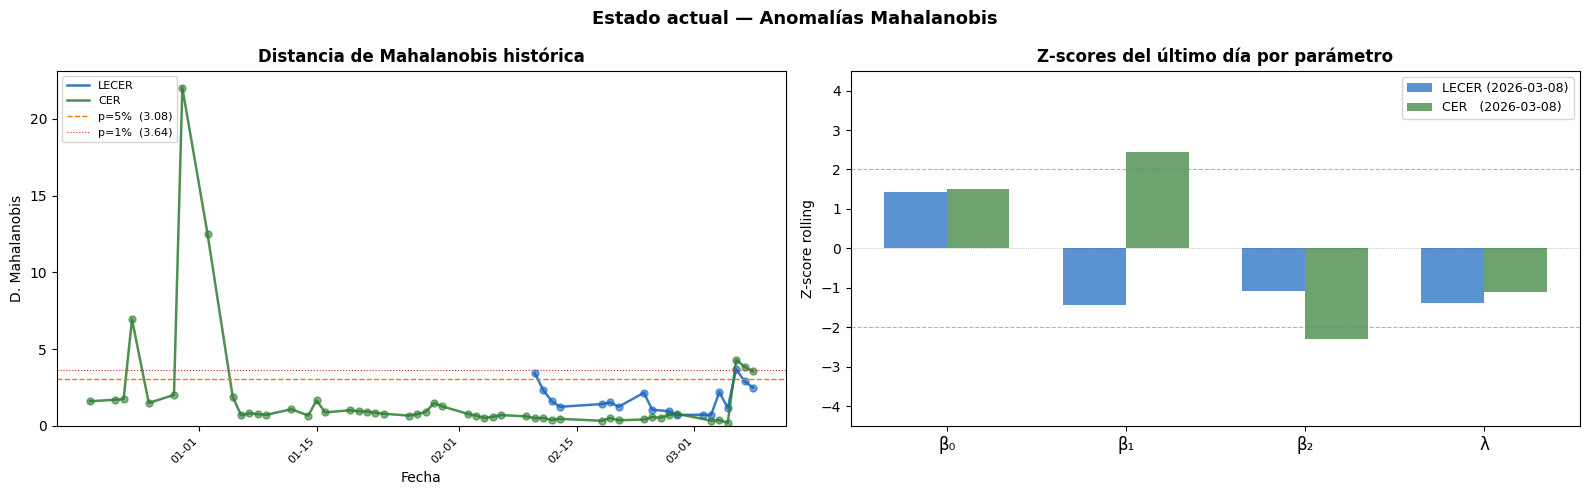

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# ── Panel izquierdo: historia de distancias ───────────────────
for series, label, color in [
    (mah_lecer, 'LECER', '#1565C0'),
    (mah_cer,   'CER',   '#2E7D32'),
]:
    s = series.dropna()
    ax1.plot(s.index, s.values, linewidth=1.8, color=color, label=label, alpha=0.85)
    ax1.scatter(s.index, s.values, s=25, color=color, alpha=0.6)

ax1.axhline(UMBRAL_95, color='#F57C00', linewidth=1.0, linestyle='--',
            label=f'p=5%  ({UMBRAL_95:.2f})')
ax1.axhline(UMBRAL_99, color='#C62828', linewidth=0.8, linestyle=':',
            label=f'p=1%  ({UMBRAL_99:.2f})')

ax1.set_title('Distancia de Mahalanobis histórica', fontsize=12, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=10)
ax1.set_ylabel('D. Mahalanobis', fontsize=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax1.legend(fontsize=8, loc='upper left')
ax1.set_ylim(bottom=0)

# ── Panel derecho: z-scores del último día ────────────────────
ultima_l = params_lecer.index.max()
ultima_c = params_cer.index.max()

labels_p = {'beta0': 'β₀', 'beta1': 'β₁', 'beta2': 'β₂', 'lam': 'λ'}
param_labels = [labels_p[c] for c in COLS_NS]
x = np.arange(len(param_labels))
w = 0.35

def get_z_hoy(zscore_df, fecha):
    if fecha not in zscore_df.index:
        return [0.0] * len(COLS_NS)
    return [
        float(zscore_df.loc[fecha, c])
        if (c in zscore_df.columns and not np.isnan(zscore_df.loc[fecha, c]))
        else 0.0
        for c in COLS_NS
    ]

z_l = get_z_hoy(zscore_lecer, ultima_l)
z_c = get_z_hoy(zscore_cer,   ultima_c)

ax2.bar(x - w/2, z_l, w, label=f'LECER ({ultima_l.date()})', color='#1565C0', alpha=0.7)
ax2.bar(x + w/2, z_c, w, label=f'CER   ({ultima_c.date()})', color='#2E7D32', alpha=0.7)
ax2.axhline( 2, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax2.axhline(-2, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax2.axhline( 0, color='black', linewidth=0.5, linestyle=':', alpha=0.4)
ax2.set_xticks(x)
ax2.set_xticklabels(param_labels, fontsize=12)
ax2.set_ylim(-4.5, 4.5)
ax2.set_title('Z-scores del último día por parámetro', fontsize=12, fontweight='bold')
ax2.set_ylabel('Z-score rolling', fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle('Estado actual — Anomalías Mahalanobis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Comentarios

### Por qué Mahalanobis como baseline

La distancia de Mahalanobis tiene tres ventajas sobre el z-score univariado:

1. **Captura correlaciones**: β₀ y β₁ en bonos argentinos están correlacionados (si el nivel sube, la pendiente tiende a comprimirse). Mahalanobis detecta cuando la *combinación* es inusual, aunque cada uno por separado parezca dentro del rango.
2. **Umbral formal**: bajo normalidad, $D_M^2 \sim \chi^2(k)$, lo que da un nivel de significancia estadístico concreto. No es un parámetro arbitrario.
3. **Pocas observaciones**: con LedoitWolf, 6-10 observaciones ya permiten estimar la covarianza regularizada. El autoencoder necesita decenas de épocas estables para ser confiable.

### Limitaciones de la muestra actual

- **LECER**: historia de ~22 días. Los primeros días de la expanding window tienen muy pocos puntos de entrenamiento; las distancias tempranas pueden ser inestables.
- **CER**: ~57 días. Más estable, pero aún corto para caracterizar la distribución de parámetros NS en distintos regímenes.
- **Supuesto de normalidad**: los parámetros NS no son normalmente distribuidos en un mercado con shocks frecuentes (cepos, elecciones, intervenciones). El umbral chi² es una aproximación; en la práctica puede estar mal calibrado. Con más historia, se puede calibrar empíricamente.
- **Sin dinámica temporal**: Mahalanobis trata cada día como i.i.d. No captura autocorrelación ni patrones secuenciales. El autoencoder con secuencias temporales puede agregar valor en este eje.

### Uso en producción (NB07)

La señal de anomalía global en NB07 combina:
- z-scores intragrupo por bono (NB04)
- Distancia de Mahalanobis NS (este notebook) — mientras no haya suficientes datos para el autoencoder
- Error de reconstrucción del autoencoder (NB06) — cuando el modelo esté entrenado

Una anomalía es más robusta cuando coincide en los tres niveles: intragrupo, Mahalanobis y autoencoder.